# NTD / FAF5 Network Links Data Quality Evaluation

## 1. Overview and Description of the Dataset

**National Transit Database (NTD) – Freight Analysis Framework (FAF) Dataset** available at:  
([https://geodata.bts.gov/maps/b33d6a096bb94ca6b5cf5d96bf68a682](https://geodata.bts.gov/maps/b33d6a096bb94ca6b5cf5d96bf68a682))


The Freight Analysis Framework (FAF), produced through a partnership between Bureau of Transportation Statistics (BTS) and Federal Highway Administration (FHWA), integrates data from a variety of sources to create a comprehensive picture of freight movement among states and major metropolitan areas by all modes of transportation. The current version is FAF5.

The Freight Analysis Framework (FAF5) - Network Links dataset was created from 2017 base year data and was published on April 11, 2022 from the Bureau of Transportation Statistics (BTS) and is part of the U.S. Department of Transportation (USDOT)/Bureau of Transportation Statistics (BTS) National Transportation Atlas Database (NTAD). The FAF (Version 5) Network contains 487,384 link features. All link features are topologically connected to permit network pathbuilding and vehicle assignment using a variety of assignment algorithms. The FAF Link and the FAF Node datasets can be used together to create a network. The link features include all roads represented in prior FAF networks, and all roads in the National Highway System (NHS) and the National Highway Freight Network (NHFN) that are currently open to traffic. Other included links provide connections between intersecting routes, and to select intermodal facilities and all U.S. counties. The network consists of over 588,000 miles of equivalent road mileage. The dataset covers the 48 contiguous States plus the District of Columbia, Alaska, and Hawaii.

## 2. Data Structure, Schema, and Metadata Assessment

The data set contains 487,394 rows and 53 columns. Where each row represents geospatial transport network link. It includes identifiers, route attributes, geography, facility classification, network designations, directional lane/speed/time fields, toll and border fields, and geometry-related length information.

In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
df = pd.read_csv('./data/NTAD_Freight_Analysis_Framework_Network_Links_1168518855865291245.csv', delimiter=',')
print('Rows:', len(df))
print('Columns:', len(df.columns))
df.head(2)

Rows: 487394
Columns: 53


C:\Users\tinew\AppData\Local\Temp\ipykernel_48700\4204625015.py:5: DtypeWarning: Columns (11,26,33,37,38,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/csv.csv', delimiter=',')


,OBJECTID,ID,LENGTH,DIR,DATA1,VERSION,Class,Class_Description,Road_Name,Sign_Rte,Rte_Type,Rte_Number,Rte_Qualifier,Country,STATE,STFIPS,County_Name,CTFIPS,Urban_Code,FAFZONE,Status,F_Class,Facility_Type,NHS,STRAHNET,NHFN,Truck,AB_Lanes,BA_Lanes,Speed_Limit,Toll_Type,Toll_Name,Toll_Link,Toll_Link_Name,HPMS_USA_RouteID,HPMS_Begin_Point,HPMS_End_Point,BorderState1,BorderState2,BorderFAF1,BorderFAF2,TRUCKTOLL,BorderLink,AddedBorderTime,AdjustSpeed,AdjustReason,AB_FinalSpeed,BA_FinalSpeed,AB_CombinedSpeed,BA_CombinedSpeed,AB_FreeFlowTime,BA_FreeFlowTime,Shape__Length
0,1,1,0.054083,1,1324805,V2021.05,19.0,Facility Access/Circulator Road,PETERSBURG FERRY TERMINAL RD,NaN,NaN,NaN,NaN,USA,AK,2.0,PETERSBURG,2195.0,99999.0,20.0,1.0,5.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.0,43.0,43.0,43.0,0.075464,0.075464,0.001009
1,2,2,0.114854,0,1324806,V2021.05,19.0,Facility Access/Circulator Road,PETERSBURG FERRY TERMINAL RD,NaN,NaN,NaN,NaN,USA,AK,2.0,PETERSBURG,2195.0,99999.0,20.0,1.0,5.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.0,43.0,43.0,43.0,0.160261,0.160261,0.002005


The schema includes numeric, text, and categorical fields.

The main schema groups are organized as follows:

- **Identifier fields:** `OBJECTID`, `ID`, `DATA1`.
- **Link and direction fields:** `LENGTH`, `DIR`.
- **Classification fields:** `Class`, `Class_Description`, `F_Class`, `Facility_Type`.
- **Geography fields:** `Country`, `STATE`, `STFIPS`, `County_Name`, `CTFIPS`, `Urban_Code`, `FAFZONE`.
- **Route fields:** `Road_Name`, `Sign_Rte`, `Rte_Type`, `Rte_Number`.
- **Network designation fields:** `NHS`, `STRAHNET`, `NHFN`, `Truck`.
- **Directional operational fields:** `AB_Lanes`, `BA_Lanes`, `Speed_Limit`, `AB_FinalSpeed`, `BA_FinalSpeed`, `AB_FreeFlowTime`, `BA_FreeFlowTime`.
- **Toll and border fields:** `Toll_Type`, `Toll_Name`, `TRUCKTOLL`, `BorderLink`, `AddedBorderTime`.
- **Geometry-related field:** `Shape__Length`.

In [3]:
schema = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(df[c].dtype) for c in df.columns],
    'non_null': [int(df[c].notna().sum()) for c in df.columns],
    'missing': [int(df[c].isna().sum()) for c in df.columns],
    'missing_pct': [df[c].isna().mean() * 100 for c in df.columns],
    'unique_values': [int(df[c].nunique(dropna=True)) for c in df.columns],
})
schema.sort_values('missing_pct', ascending=False)

,column,dtype,non_null,missing,missing_pct,unique_values
42,BorderLink,float64,168,487226,99.965531,1
43,AddedBorderTime,float64,168,487226,99.965531,1
33,Toll_Link_Name,object,1135,486259,99.767129,659
32,Toll_Link,float64,1243,486151,99.744970,1
41,TRUCKTOLL,float64,3245,484149,99.334214,2266
40,BorderFAF2,float64,4172,483222,99.144019,129
39,BorderFAF1,float64,4172,483222,99.144019,127
26,Truck,object,4365,483029,99.104421,3
38,BorderState2,object,5863,481531,98.797072,46
37,BorderState1,object,5983,481411,98.772451,47


In [4]:
df.describe()

,OBJECTID,ID,LENGTH,DIR,DATA1,Class,STFIPS,CTFIPS,Urban_Code,FAFZONE,Status,F_Class,Facility_Type,NHS,STRAHNET,NHFN,AB_Lanes,BA_Lanes,Speed_Limit,Toll_Type,Toll_Link,HPMS_Begin_Point,HPMS_End_Point,BorderFAF1,BorderFAF2,TRUCKTOLL,BorderLink,AddedBorderTime,AdjustSpeed,AB_FinalSpeed,BA_FinalSpeed,AB_CombinedSpeed,BA_CombinedSpeed,AB_FreeFlowTime,BA_FreeFlowTime,Shape__Length
count,487394.000000,4.873940e+05,487394.000000,487394.000000,4.873940e+05,487390.000000,485636.000000,481840.000000,481840.000000,485636.000000,483598.000000,465623.000000,393114.000000,322026.000000,101707.000000,86859.000000,463206.000000,153802.000000,487162.000000,8012.000000,1243.0,99440.000000,99440.000000,4172.000000,4172.000000,3245.000000,168.0,168.0,38858.000000,483875.000000,483875.000000,483875.000000,483875.000000,483875.000000,483542.000000,4.873940e+05
mean,243697.500000,9.748118e+05,1.206835,0.653264,8.932146e+05,15.903156,29.773581,29867.966304,66716.228067,301.828413,1.000066,2.419155,3.399164,8.913159,6.260936,6.070344,2.011388,1.666110,47.505957,1.047928,1.0,66.628119,67.505841,301.390700,303.810403,10.053736,1.0,60.0,-4.750722,43.153303,42.471254,43.534814,42.852764,1.656925,1.662630,2.021513e-02
std,140698.672888,5.627960e+05,3.584868,0.477614,3.461475e+05,5.162112,16.101308,16135.103548,32796.567625,161.609532,0.009753,1.333274,1.578805,3.633977,5.058626,4.921896,1.051111,0.739399,13.220967,0.304257,0.0,115.650480,115.728760,150.770238,157.075850,148.253598,0.0,0.0,1.999975,13.604312,13.492831,13.487029,13.331422,9.614979,9.607410,6.639616e-02
min,1.000000,1.000000e+00,0.000000,-1.000000,2.000000e+00,11.000000,1.000000,1001.000000,199.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,5.000000,1.000000,1.0,-6.870000,-6.528595,11.000000,11.000000,0.002366,1.0,60.0,-12.200000,4.468367,-6.750000,4.468367,0.000000,0.000000,-6.426970,9.996506e-07
25%,121849.250000,4.874472e+05,0.126454,0.000000,6.956222e+05,12.000000,17.000000,17031.000000,41212.000000,171.000000,1.000000,1.000000,2.000000,7.000000,1.000000,1.000000,1.000000,1.000000,35.000000,1.000000,1.0,4.464053,5.318180,181.000000,172.000000,0.120421,1.0,60.0,-5.775000,30.000000,29.500000,33.000000,29.500000,0.196440,0.199954,2.075014e-03
50%,243697.500000,9.748635e+05,0.295451,1.000000,9.600420e+05,14.000000,30.000000,30021.000000,74179.000000,300.000000,1.000000,2.000000,4.000000,11.000000,11.000000,2.000000,2.000000,2.000000,45.000000,1.000000,1.0,16.670088,17.563574,311.000000,319.000000,0.806638,1.0,60.0,-4.425000,40.000000,38.500000,40.000000,38.500000,0.446114,0.451604,4.873769e-03
75%,365545.750000,1.462280e+06,0.781605,1.000000,1.178870e+06,22.000000,45.000000,45061.000000,99998.000000,459.000000,1.000000,3.000000,4.000000,12.000000,11.000000,11.000000,2.000000,2.000000,55.000000,1.000000,1.0,71.465133,72.608534,421.000000,429.000000,3.050000,1.0,60.0,-3.000000,53.000000,53.000000,54.000000,53.000000,1.074189,1.084175,1.292820e-02
max,487394.000000,1.949504e+06,739.858582,1.000000,1.359962e+06,50.000000,56.000000,56045.000000,99999.000000,560.000000,5.000000,10.000000,7.000000,12.000000,12.000000,12.000000,17.000000,12.000000,85.000000,3.000000,1.0,878.780650,879.427677,560.000000,560.000000,6789.000000,1.0,60.0,-1.391230,80.000000,83.000000,80.000000,83.000000,4439.151489,4439.151489,1.717578e+01


Top 3 columns with outliers (Magnitude X IQR): `TRUCKTOLL`, `AB_FreeFlowTime`, `BA_FreeFlowTime`  

These fields require busines-context validation because some high values are associated with ferry or long-distance links and may be valid rather than erroneous.

In [24]:
# 4. Search for outliers and anomalies using IQR (Outliers & Anomalies)
print("--- STATISTICAL OUTLIER DETECTION (IQR METHOD) ---")

# Select only numeric columns for anomaly analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns

outliers_summary = []
for col in numeric_cols:
    # Ignore ID columns and regional code columns, because IQR is not meaningful for them
    if col.lower() in [
        "objectid",
        "id",
        "stfips",
        "urban_code",
        "version",
        "dir",
    ] or "fips" in col.lower():
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count the number of rows outside the IQR whiskers
    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[
        0
    ]
    outliers_pct = (outliers_count / len(df)) * 100

    col_min = df[col].min()
    col_max = df[col].max()

    lower_magnitude = max(0, lower_bound - col_min)
    upper_magnitude = max(0, col_max - upper_bound)
    outlier_magnitude = max(lower_magnitude, upper_magnitude)

    if IQR != 0:
        outlier_magnitude_iqr = outlier_magnitude / IQR
    else:
        outlier_magnitude_iqr = np.nan

    outliers_summary.append(
        {
            "Column": col,
            "Min": col_min,
            "Max": col_max,
            # "Lower Bound": lower_bound,
            # "Upper Bound": upper_bound,
            "Outliers Count": outliers_count,
            "Outliers (%)": round(outliers_pct, 2),
            "Outlier Magnitude": round(outlier_magnitude, 2),
            "Outlier Magnitude (x IQR)": round(outlier_magnitude_iqr, 2),
        }
    )

outliers_df = pd.DataFrame(outliers_summary).sort_values(
    by="Outliers (%)", ascending=False
)

outliers_df[outliers_df["Outliers Count"] > 0]


--- STATISTICAL OUTLIER DETECTION (IQR METHOD) ---


,Column,Min,Max,Outliers Count,Outliers (%),Outlier Magnitude,Outlier Magnitude (x IQR)
0,LENGTH,0.000000e+00,739.858582,73126,15.00,738.09,1126.60
29,Shape__Length,9.996506e-07,17.175784,72846,14.95,17.15,1579.87
27,AB_FreeFlowTime,0.000000e+00,4439.151489,71892,14.75,4436.76,5054.70
28,BA_FreeFlowTime,-6.426970e+00,4439.151489,71836,14.74,4436.74,5017.68
10,AB_Lanes,0.000000e+00,17.000000,45954,9.43,13.50,13.50
15,HPMS_Begin_Point,-6.870000e+00,878.780650,12701,2.61,706.81,10.55
16,HPMS_End_Point,-6.528595e+00,879.427677,12696,2.60,705.88,10.49
2,Class,1.100000e+01,50.000000,3986,0.82,13.00,1.30
11,BA_Lanes,0.000000e+00,12.000000,3826,0.78,8.50,8.50
5,F_Class,1.000000e+00,10.000000,1454,0.30,4.00,2.00


## 3. Data Quality Findings and Identified Issues

<!-- Original draft preserved:
### 3. Data quality findings and identified issues.
-->

Schema is not consistend and contains many missing rows. Most of them can be grouped into data silos.

### Finding 1: Missing Values and Data Silos

                   Missing Rows  Percentage (%)
BorderLink               487226       99.965531
AddedBorderTime          487226       99.965531
Toll_Link_Name           486259       99.767129
Toll_Link                486151       99.744970
TRUCKTOLL                484149       99.334214
BorderFAF2               483222       99.144019
BorderFAF1               483222       99.144019
Truck                    483029       99.104421
BorderState2             481531       98.797072
BorderState1             481411       98.772451
Rte_Qualifier            480033       98.489723
Toll_Name                479402       98.360259
Toll_Type                479382       98.356155
AdjustSpeed              448536       92.027395
AdjustReason             448188       91.955995
NHFN                     400535       82.178894
HPMS_Begin_Point         387954       79.597615
HPMS_End_Point           387954       79.597615
HPMS_USA_RouteID         387931       79.592896
STRAHNET                 385687       79

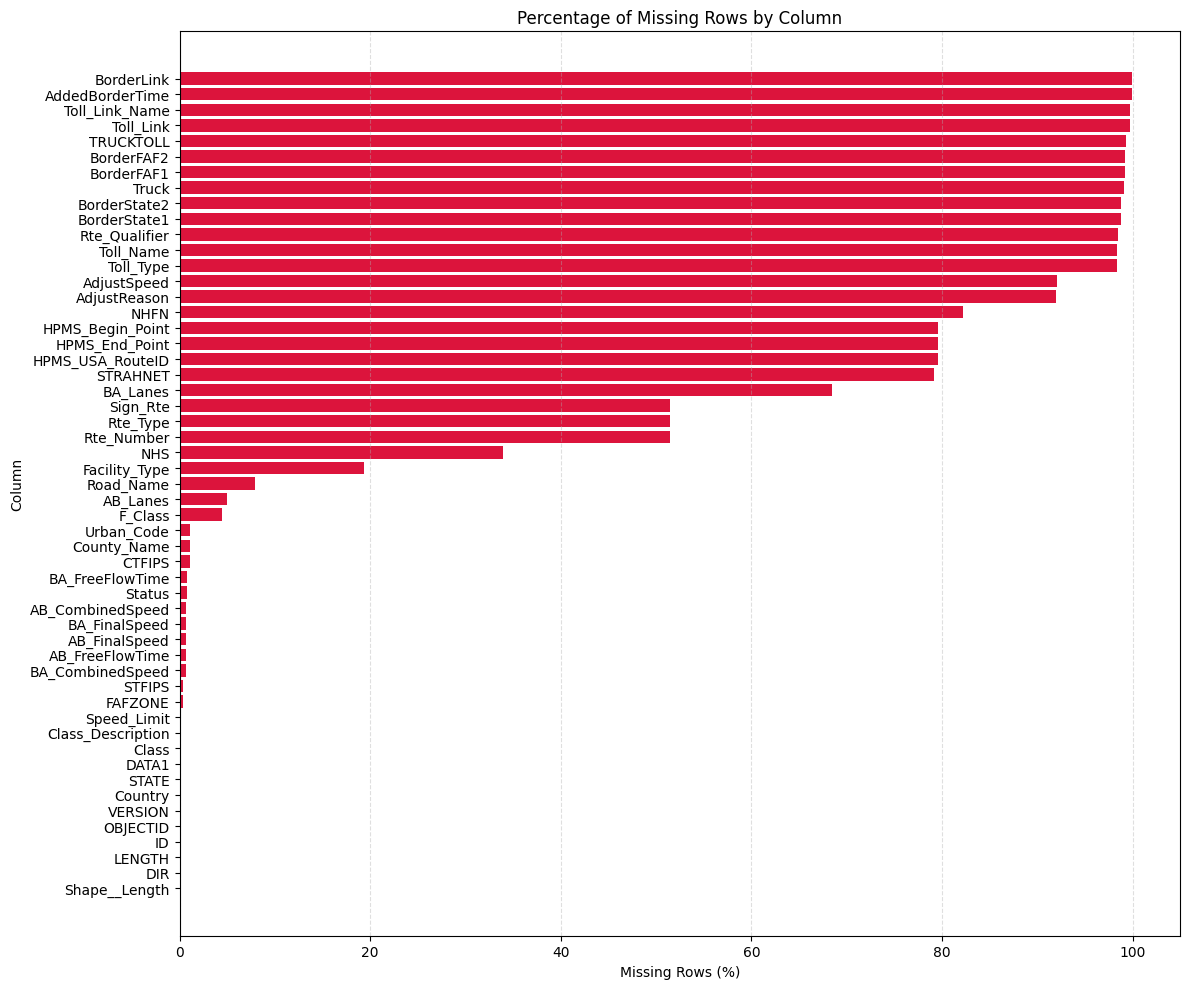

In [6]:
import matplotlib.pyplot as plt

missing_values = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame(
    {
        "Missing Rows": df.isnull().sum(),
        "Percentage (%)": missing_values
    }
).sort_values(by="Percentage (%)", ascending=False)

critical_missing = missing_df[missing_df["Missing Rows"] >= 0]

if not critical_missing.empty:
    print(critical_missing)

    plt.figure(figsize=(12, 10))
    plt.barh(
        critical_missing.index,
        critical_missing["Percentage (%)"],
        color="crimson"
    )

    plt.gca().invert_yaxis()
    plt.xlabel("Missing Rows (%)")
    plt.ylabel("Column")
    plt.title("Percentage of Missing Rows by Column")
    plt.grid(axis="x", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

Below, we group the columns into data silos by % of missing data and investigate correlations between them.

In [7]:
print("--- FULL AUDIT OF STRUCTURE AND DATA SILOS ---")

# 1. Calculate the exact missing-value percentage for ALL 53 columns (without a top-20 limit)
total_rows = len(df)
all_missing = (
    df.isnull()
    .sum()
    .reset_index()
    .rename(columns={"index": "Column", 0: "Missing_Rows"})
)
all_missing["Missing_Percentage"] = (all_missing["Missing_Rows"] / total_rows) * 100
all_missing = all_missing.sort_values(by="Missing_Percentage", ascending=False)

print(f"Total columns in the dataset: {len(all_missing)}")


# 2. Group columns into your "silo clusters" for the report
def cluster_sparsity(pct):
    if pct == 0:
        return "0% (Perfect/Core Fields)"
    elif pct <= 8:
        return "0% - 8% (Minor Incompleteness)"
    elif pct <= 33:
        return "8% - 33% (Regional/State Specific Data)"
    elif pct <= 55:
        return "51% - 52% (Specific Infrastructure Silo)"
    elif pct <= 70:
        return "68% (Niche Network Attributes)"
    elif pct <= 85:
        return "79% - 82% (High Sparsity / Federal Sub-networks)"
    elif pct <= 95:
        return "91% - 92% (Operational Adjustments Silo)"
    else:
        return "98% - 100% (Critical Sparsity / Edge Cases / Border Only)"


all_missing["Silo_Cluster"] = all_missing["Missing_Percentage"].apply(
    cluster_sparsity
)

print("\n📊 COLUMN DISTRIBUTION BY DATA SILO CLUSTERS (FOR REPORTING):")
cluster_summary = (
    all_missing.groupby("Silo_Cluster")["Column"]
    .apply(list)
    .reset_index()
)
for idx, row in cluster_summary.iterrows():
    print(f"\n📁 Cluster: {row['Silo_Cluster']}")
    print(f"   Columns ({len(row['Column'])} total): {', '.join(row['Column'])}")

print("\n" + "=" * 50 + "\n")

# 3. SCHEMA DRIFT CHECK: Does the schema break depending on VERSION?
print("--- SCHEMA DRIFT ANALYSIS BY VERSION COLUMN ---")
if "VERSION" in df.columns:
    versions = df["VERSION"].unique()
    print(f"Detected versions/reporting periods in the 2026 data: {versions}")

    # Check whether key-field completeness changes from version to version
    for v in versions:
        v_df = df[df["VERSION"] == v]
        print(f"\nAnalysis of version subset {v} (Rows: {len(v_df)}):")
        # Show the top 5 empty columns for this specific version
        v_missing = (v_df.isnull().sum() / len(v_df)) * 100
        print(v_missing[v_missing > 0].sort_values(ascending=False).head(5))
else:
    print("VERSION column was not found for drift analysis.")

print("\n" + "=" * 50 + "\n")

# 4. MISSINGNESS CORRELATION MATRIX (Shows which columns become empty AT THE SAME TIME)
print("--- MISSINGNESS CORRELATION (Identifying Systemic Data Silos) ---")
# Select only columns that contain at least some missing values
cols_with_nan = df.columns[df.isnull().any()].tolist()
if len(cols_with_nan) > 1:
    # Create a boolean matrix (True if Null)
    null_pattern = df[cols_with_nan].isnull()
    # Calculate correlation: if 1.0, columns are always empty together (one silo)
    null_corr = null_pattern.corr()

    # Output pairs with perfect missingness correlation (1.0)
    high_corr_pairs = []
    for i in range(len(null_corr.columns)):
        for j in range(i + 1, len(null_corr.columns)):
            if null_corr.iloc[i, j] > 0.99:
                high_corr_pairs.append(
                    (null_corr.columns[i], null_corr.columns[j])
                )

    print(
        f"Found {len(high_corr_pairs)} column pairs that become empty AT THE SAME TIME "
        f"(evidence of strict data silos):"
    )
    for pair in high_corr_pairs[:15]:  # Output the first 15 pairs
        print(f"   - {pair[0]} <---> {pair[1]}")

--- FULL AUDIT OF STRUCTURE AND DATA SILOS ---
Total columns in the dataset: 53

📊 COLUMN DISTRIBUTION BY DATA SILO CLUSTERS (FOR REPORTING):

📁 Cluster: 0% (Perfect/Core Fields)
   Columns (9 total): DATA1, STATE, Country, VERSION, OBJECTID, ID, LENGTH, DIR, Shape__Length

📁 Cluster: 0% - 8% (Minor Incompleteness)
   Columns (18 total): Road_Name, AB_Lanes, F_Class, Urban_Code, County_Name, CTFIPS, BA_FreeFlowTime, Status, AB_CombinedSpeed, BA_FinalSpeed, AB_FinalSpeed, AB_FreeFlowTime, BA_CombinedSpeed, STFIPS, FAFZONE, Speed_Limit, Class_Description, Class

📁 Cluster: 51% - 52% (Specific Infrastructure Silo)
   Columns (4 total): Sign_Rte, Rte_Type, Rte_Number, NHS

📁 Cluster: 68% (Niche Network Attributes)
   Columns (1 total): BA_Lanes

📁 Cluster: 79% - 82% (High Sparsity / Federal Sub-networks)
   Columns (5 total): NHFN, HPMS_Begin_Point, HPMS_End_Point, HPMS_USA_RouteID, STRAHNET

📁 Cluster: 8% - 33% (Regional/State Specific Data)
   Columns (1 total): Facility_Type

📁 Cluster:

The missingness correlation analysis found **24 column pairs** that become empty at the same time, which is evidence of structured data silos. Examples include:

- `Sign_Rte` <--> `Rte_Type`
- `Sign_Rte` <--> `Rte_Number`
- `Rte_Type` <--> `Rte_Number`
- `STFIPS` <--> `FAFZONE`
- `County_Name` <--> `CTFIPS`
- `BorderLink` <--> `AddedBorderTime`

**These are data silos, not random groups**: some fields are populated only for certain network types, geographies, or enrichment sources.

### Finding 2: Inaccurate or Inconsistent Data

In [25]:
# 5. Logical checks for "Inaccurate / Inconsistent Data"
print("--- LOGICAL INCONSISTENCIES ---")
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Check 1: Negative values in fields where they should not exist (length, speed, volumes)
negative_checks = {}
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        negative_checks[col] = neg_count

if negative_checks:
    print("⚠️ Negative values found in strictly positive fields:")
    for k, v in negative_checks.items():
        print(f"   - Column '{k}': {v} rows with negative values.")
else:
    print("✅ Negative-value test passed (all metrics are >= 0).")

# Check 2: Anomalous speed limits (for example, Speed_Limit == 0 or > 100 mph)
if "Speed_Limit" in df.columns:
    bad_speed = df[(df["Speed_Limit"] <= 0) | (df["Speed_Limit"] > 90)].shape[0]
    print(f"   - Rows with unrealistic Speed_Limit (<=0 or >90): {bad_speed}")

# Check 3: Zero length where data exists
if "LENGTH" in df.columns:
    zero_len = df[df["LENGTH"] <= 0].shape[0]
    print(f"   - Rows with zero or negative LENGTH: {zero_len}")

--- LOGICAL INCONSISTENCIES ---
⚠️ Negative values found in strictly positive fields:
   - Column 'DIR': 391 rows with negative values.
   - Column 'HPMS_Begin_Point': 25 rows with negative values.
   - Column 'HPMS_End_Point': 22 rows with negative values.
   - Column 'AdjustSpeed': 38858 rows with negative values.
   - Column 'BA_FinalSpeed': 26 rows with negative values.
   - Column 'BA_FreeFlowTime': 26 rows with negative values.
   - Rows with unrealistic Speed_Limit (<=0 or >90): 0
   - Rows with zero or negative LENGTH: 2


### Finding 3: Inconsistent `Class_Description` Values

`Class_Description` appears to contain manual or non-standardized text variants.

In [9]:
# Class code to label consistency check
class_label_counts = (
    df.groupby(['Class', 'Class_Description'], dropna=False)
      .size()
      .reset_index(name='rows')
      .sort_values(['Class', 'rows'], ascending=[True, False])
)
classes_with_multiple_labels = (
    class_label_counts.groupby('Class', dropna=False)
    .size()
    .reset_index(name='label_count')
    .query('label_count > 1')
)
class_label_counts[class_label_counts['Class'].isin(classes_with_multiple_labels['Class'])]

,Class,Class_Description,rows
4,14.0,Arterial or Major Collector,200129
6,14.0,Frontage/Service Road,3
3,14.0,Arterial or Major Collecor,1
5,14.0,Artial or Major Collector,1
13,16.0,Frontage/Service Road,11226
15,16.0,Frontage/Servise Road,13
9,16.0,Collector/Distributor Lane,12
11,16.0,Frontage/Serivce Road,12
8,16.0,Arterial or Major Collector,6
12,16.0,Frontage/Service Rd,2


### Finding 4: Non-USA Geography Fields Have 100% Missing Values for Some Attributes

fields are missing: `STFIPS`, `County_Name`, `CTFIPS`, `Urban_Code`, and `FAFZONE`.

In [10]:
# Non-USA geography completeness
geo_cols = ['Country','STATE','STFIPS','County_Name','CTFIPS','Urban_Code','FAFZONE']
non_usa_geo_missing = df[df['Country'].ne('USA')][geo_cols].isna().mean().mul(100).rename('missing_pct').reset_index()
non_usa_geo_missing.rename(columns={'index': 'column'})

,column,missing_pct
0,Country,0.0
1,STATE,0.0
2,STFIPS,100.0
3,County_Name,100.0
4,CTFIPS,100.0
5,Urban_Code,100.0
6,FAFZONE,100.0


### Finding 5: Directional Fields Are Structurally Difficult to Interpret

There are inconsistencies in the `AB_Lanes` and the `BA_Lanes` records in assumption that `DIR` have correspondence with them.   

For instance, there are cases when `AB_Lanes` and `BA_Lanes` are empty at the same time. Other combinations of missing values tables are shown below.

In [11]:
pd.crosstab(
    df['DIR'],
    [df['AB_Lanes'].isna().rename('AB_Lanes_missing'), df['BA_Lanes'].isna().rename('BA_Lanes_missing')],
    dropna=False,
)

AB_Lanes_missing   False         True        
BA_Lanes_missing   False   True  False  True 
DIR                                          
-1                   110     234     0     47
 0                152972     178    29  15036
 1                   684  309028     7   9069

Assuming that `DIR`=0 means two-way movement and `DIR`=1 means one-way movement, combinations in red look like an ambiguity and require verification.

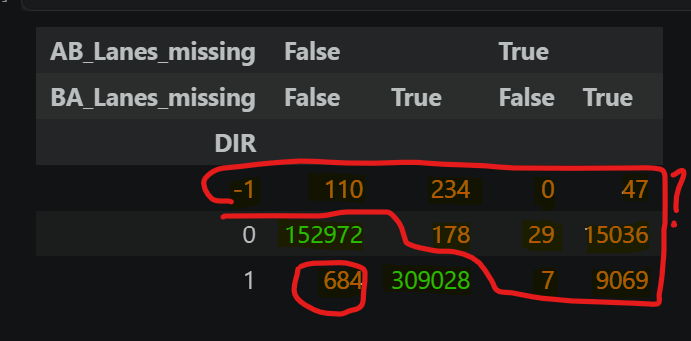

<!-- Original draft preserved:
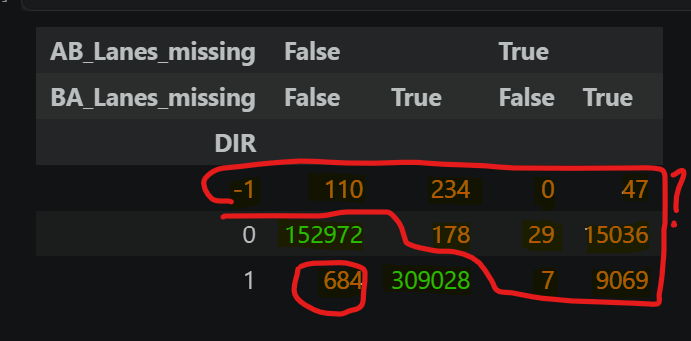
-->

### Finding 6: Completeness Drift Across Reporting or Load Periods

Assuming `DATA1`it is a dummy timestamp column, we divide our dataframe into 5 equal subsets and compare their % of missing data. The columns and schema are the same, however, missing data drift was detected.

In [19]:
load_group_labels = [
    'G1 lowest DATA1',
    'G2',
    'G3',
    'G4',
    'G5 highest DATA1',
]

df['_DATA1_Load_Group'] = pd.qcut(
    df['DATA1'],
    q=5,
    labels=load_group_labels,
    duplicates='drop'
)

group_profile = (
    df.groupby('_DATA1_Load_Group', observed=False)
      .agg(
          Rows=('DATA1', 'size'),
          Min_DATA1=('DATA1', 'min'),
          Max_DATA1=('DATA1', 'max'),
          Unique_States=('STATE', lambda s: s.nunique(dropna=True)),
          Unique_Classes=('Class', lambda s: s.nunique(dropna=True)),
      )
      .reset_index()
)
print('Subsets')
group_profile


Subsets


,_DATA1_Load_Group,Rows,Min_DATA1,Max_DATA1,Unique_States,Unique_Classes
0,G1 lowest DATA1,97479,2,613485,48,9
1,G2,97479,613495,852437,32,14
2,G3,97478,852439,1058601,36,13
3,G4,97479,1058602,1221797,48,12
4,G5 highest DATA1,97479,1221798,1359962,57,16


All the columns in the heatmap below have different missing values amount across periods. The most outstanding of them are:
   - `BA_Lanes` missing rate changes from roughly 11% to almost 100%.
   - `Facility_Type` missing rate changes from near 0% to above 40%.
   - `Road_Name` missing rate changes from near 0% to about 26%.

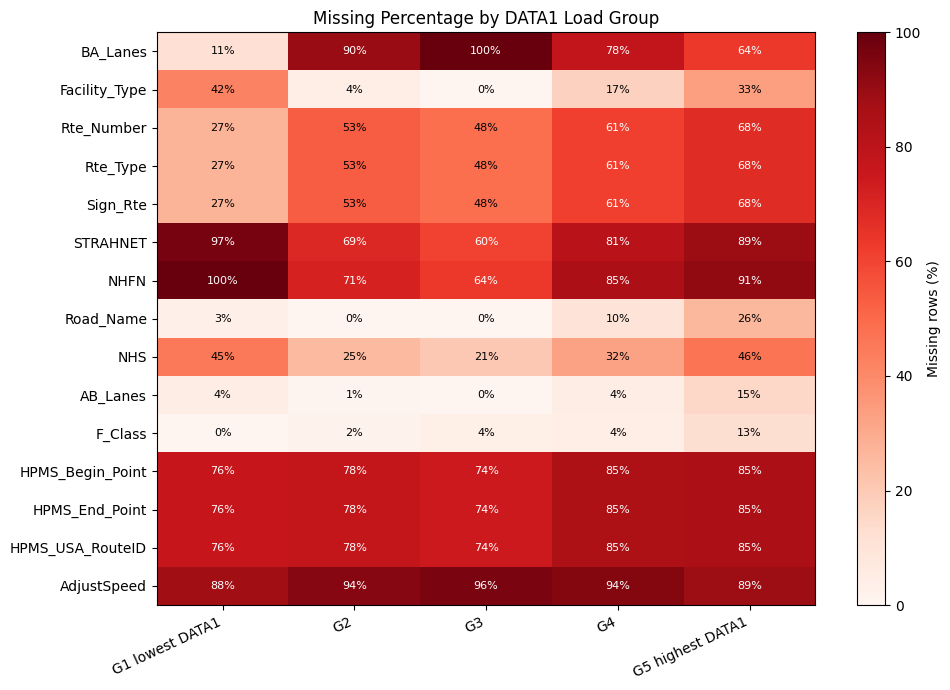

In [23]:
analysis_cols = [c for c in df.columns if c != '_DATA1_Load_Group']
missing_by_group = (
    df[analysis_cols + ['_DATA1_Load_Group']]
      .set_index('_DATA1_Load_Group')
      .isna()
      .groupby(level=0, observed=False)
      .mean()
      .mul(100)
)

missing_variation = pd.DataFrame({
    'Min Missing %': missing_by_group.min(axis=0),
    'Max Missing %': missing_by_group.max(axis=0),
})
missing_variation['Range Missing %'] = (
    missing_variation['Max Missing %'] - missing_variation['Min Missing %']
)
missing_variation = missing_variation.sort_values('Range Missing %', ascending=False)

top_cols = missing_variation.head(15).index.tolist()
heatmap_data = missing_by_group[top_cols].T

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='Reds', vmin=0, vmax=100)

ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns.astype(str), rotation=25, ha='right')
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_title('Missing Percentage by DATA1 Load Group')

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        text_color = 'white' if value >= 60 else 'black'
        ax.text(j, i, f'{value:.0f}%', ha='center', va='center', fontsize=8, color=text_color)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Missing rows (%)')
plt.tight_layout()
plt.show()


### Finding 7: Temporal Mismatch: task asks for a 2026 evaluation, but all records at the task's link have `VERSION = V2021.05` with 2022 publication date.

### Finding 8: Absence of geometry columns (such as longitude and latitude)

## 4. Risk Assessment Related to Data Reliability and Usability

<!-- Original draft preserved:
### 4. Risk assessment related to data reliability and usability.
-->

### Findings:
1. **Missing Values and Data Silos**: High missingness (up to 50%) in almost 50% of the columns.
2. **Inaccurate or Inconsistent Data**: negative speed, `DIR`, unrealistic speed limits.
3. Inconsistent `Class_Description` Values
4. **Non-USA Geography Fields Have 100% Missing Values** for `STFIPS`, `County_Name`, `CTFIPS`, `Urban_Code`, and `FAFZONE`
5. **Directional Fields Are Structurally Difficult to Interpret**: `AB_Lanes`, `BA_Lanes` in relation to `DIR` such as other `AB_`, `BA_` columns.
6. **Completeness Drift Across Reporting Periods**: data missings drifts depend on DATA1 (in assumption this is proxy timestamp load)
7. **Temporal Mismatch**: task asks for a 2026 evaluation, but all records at the task's link have `VERSION = V2021.05` with 2022 publication date.
8. **Absence of geometry columns** (such as longitude and latitude)

Production Risk: Medium-to-high

## 5. Recommendations for Data Cleansing, Governance, and Validation

### Corresponding Recommendations:
1. **Implement automated data-quality checks.**    
Add automated ingestion checks for uniqueness, missingness thresholds, code-domain validation, numeric range validation, schema drift, and batch-level completeness drift.


2. **Standardize categorical fields.**   
Standardize `Class_Description` using an official code-value lookup table. The same for `DIR`, `Status`, `Facility_Type`, `NHS`, `NHFN`, `STRAHNET`, `Toll_Type`, and `Truck`.


3. **Define clear missing-value rules.**    
Non-USA fields which are not applicable should include 'Not Applicable' to avoid perceiving them as missing data. Missing values should distinguish between unknown, not applicable, and not collected. Treat non-USA rows and cross-border records as a separate integration case.


4. **Validate directional fields.**    
such as `AB_Lanes`, `BA_Lanes`, `AB_FinalSpeed`, `BA_FinalSpeed`, `AB_FreeFlowTime`, and `BA_FreeFlowTime` against official rules for one-way and two-way links.



5. **Resolve the reporting-date mismatch.**    
Resolve the 2026 versus 2022 date mismatch: The dataset should include a verified `data_year` field


6. **Use authoritative geometry.**    
Use geometry from the authoritative source geodatabase for geospatial validation and map-based analytics


## 6. Conclusion on Production-Grade Analytics Readiness

The dataset is suitable only for **limited exploratory analysis and approximate transportation network modeling** if the columns highlighted in green in the snapshot below are sufficient for the intended purpose.

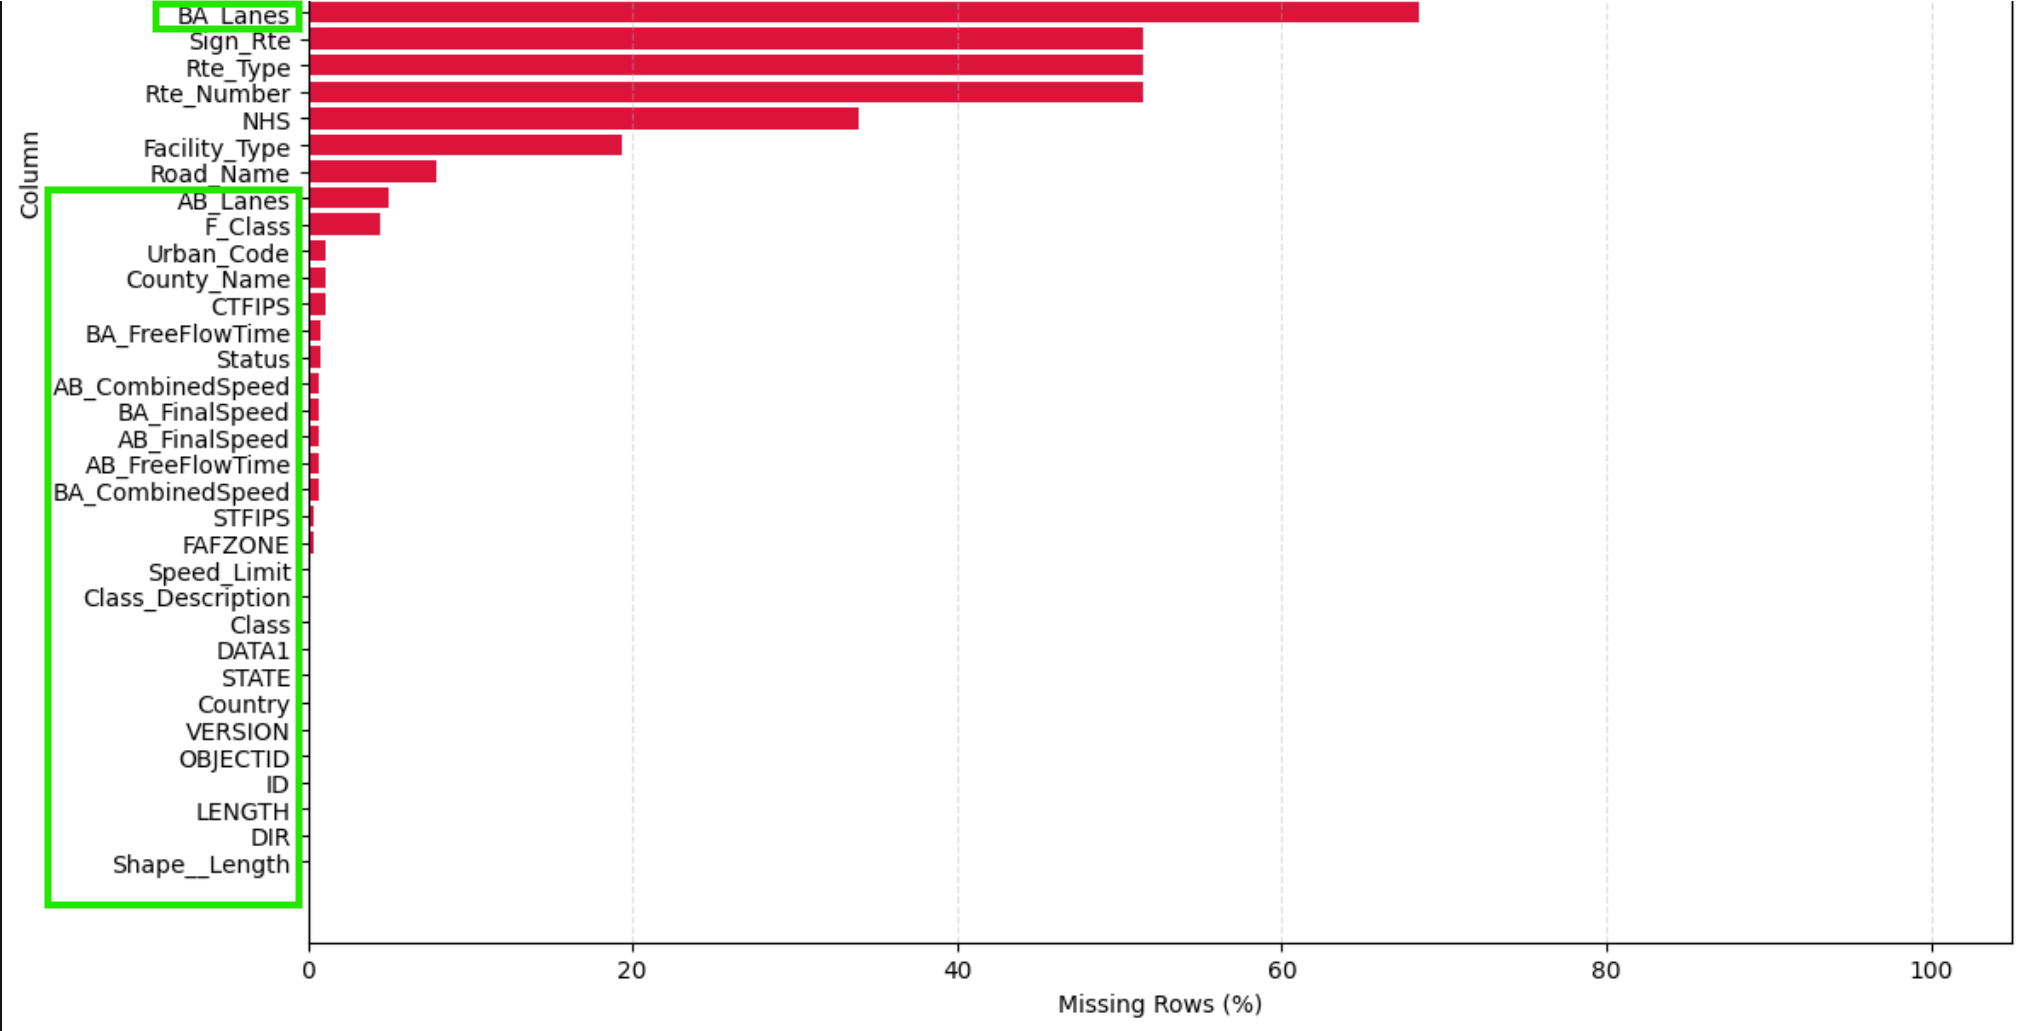

However, the dataset is **not reliable as-is for a production-grade analytics platform** without additional validation, documentation, and governance.

The main reasons are the lack of confirmed 2026 temporal metadata, missingness in important fields, inconsistent categorical labels, ambiguous directional fields, and the absence of full geometry.

**These issues can affect routing, travel-time estimation, cost modeling, reporting, and integration with external reference datasets.**

Final recommendation: **reject the current dataset version for production use until temporal validity, schema documentation, and data-quality rules are confirmed.** After cleansing and governance, it could be used in production-grade analytics platform.